<h1>Importing Data</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv")

In [3]:
print(df)

            id         hotel  is_canceled  lead_time  arrival_date_year  \
0            1  Resort Hotel          0.0      342.0               2015   
1            2  Resort Hotel          0.0      737.0               2015   
2            3  Resort Hotel          0.0        7.0               2015   
3            4  Resort Hotel          0.0       13.0               2015   
4            5  Resort Hotel          0.0       14.0               2015   
...        ...           ...          ...        ...                ...   
119385  119386    City Hotel          0.0       23.0               2017   
119386  119387    City Hotel          0.0      102.0               2017   
119387  119388    City Hotel          0.0       34.0               2017   
119388  119389    City Hotel          0.0      109.0               2017   
119389  119390    City Hotel          0.0      205.0               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                   

In [4]:
print(df.shape)
print(df.dtypes)

(119390, 33)
id                                  int64
hotel                              object
is_canceled                       float64
lead_time                         float64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number          float64
arrival_date_day_of_month         float64
stays_in_weekend_nights           float64
stays_in_week_nights              float64
adults                            float64
children                          float64
babies                            float64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                 float64
previous_cancellations            float64
previous_bookings_not_canceled    float64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                   float64
deposit_type         

In [5]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)

['id' 'is_canceled' 'lead_time' 'arrival_date_year'
 'arrival_date_week_number' 'arrival_date_day_of_month'
 'stays_in_weekend_nights' 'stays_in_week_nights' 'adults' 'children'
 'babies' 'is_repeated_guest' 'previous_cancellations'
 'previous_bookings_not_canceled' 'booking_changes' 'agent' 'company'
 'days_in_waiting_list' 'adr' 'required_car_parking_spaces'
 'total_of_special_requests']


In [6]:
df_nonnumeric = df.select_dtypes(exclude=[np.number])
nonnumeric_cols = df_nonnumeric.columns.values
print(nonnumeric_cols)

['hotel' 'arrival_date_month' 'meal' 'country' 'market_segment'
 'distribution_channel' 'reserved_room_type' 'assigned_room_type'
 'deposit_type' 'customer_type' 'reservation_status'
 'reservation_status_date']


<h2> Data Preprocessing</h2>

In [7]:
# Handling missing values
# strategy: look for rows and columns deletion if many missing values
# strategy 2: replace with mode (categorical) and mean or median in the case of numerical
plt.style.use('ggplot')
cols = df.columns

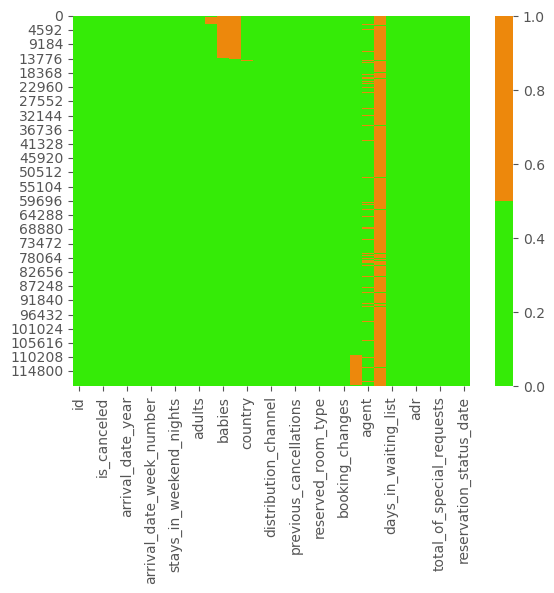

In [8]:
sns.heatmap(df[cols].isnull(), cmap = sns.color_palette(['#35eb07','#ed880c']))
plt.show()

In [9]:
for col in df.columns:
    pct_miss = np.mean(df[col].isnull())
    if pct_miss > 0:
        print(f"{col} - {pct_miss*100}%")

is_canceled - 0.008375910880308233%
lead_time - 0.008375910880308233%
arrival_date_week_number - 0.011726275232431527%
arrival_date_day_of_month - 0.011726275232431527%
stays_in_weekend_nights - 0.011726275232431527%
stays_in_week_nights - 0.011726275232431527%
adults - 0.011726275232431527%
children - 2.061311667643856%
babies - 11.32171873691264%
meal - 11.477510679286372%
country - 0.4204707261914733%
market_segment - 0.011726275232431527%
distribution_channel - 0.011726275232431527%
is_repeated_guest - 0.011726275232431527%
previous_cancellations - 0.011726275232431527%
previous_bookings_not_canceled - 0.011726275232431527%
reserved_room_type - 0.011726275232431527%
assigned_room_type - 0.011726275232431527%
booking_changes - 0.011726275232431527%
deposit_type - 8.243571488399363%
agent - 13.697127062568054%
company - 94.30689337465449%
days_in_waiting_list - 0.011726275232431527%
customer_type - 0.011726275232431527%
adr - 0.011726275232431527%
required_car_parking_spaces - 0.0117

In [10]:
df = df.drop(['company'],axis=1)

In [11]:
# lets drop the rows with missing values
print(df.shape)

(119390, 32)


In [12]:
for col in df.columns:
    num_miss = df[col].isnull()
    tot_num_missing = np.sum(num_miss)
    if tot_num_missing > 0:
        print("Creating duplicate column for: ")
        print(f'{col}_missing')
        df[f'{col}_missing'] = num_miss
print("Check the shape after adding duplicate column")
print(df.shape)

Creating duplicate column for: 
is_canceled_missing
Creating duplicate column for: 
lead_time_missing
Creating duplicate column for: 
arrival_date_week_number_missing
Creating duplicate column for: 
arrival_date_day_of_month_missing
Creating duplicate column for: 
stays_in_weekend_nights_missing
Creating duplicate column for: 
stays_in_week_nights_missing
Creating duplicate column for: 
adults_missing
Creating duplicate column for: 
children_missing
Creating duplicate column for: 
babies_missing
Creating duplicate column for: 
meal_missing
Creating duplicate column for: 
country_missing
Creating duplicate column for: 
market_segment_missing
Creating duplicate column for: 
distribution_channel_missing
Creating duplicate column for: 
is_repeated_guest_missing
Creating duplicate column for: 
previous_cancellations_missing
Creating duplicate column for: 
previous_bookings_not_canceled_missing
Creating duplicate column for: 
reserved_room_type_missing
Creating duplicate column for: 
assigne

In [13]:
ismissing_cols = [col for col in df.columns if '_missing' in col]
df['tot_num_missing'] = df[ismissing_cols].sum(axis=1)
print(df.shape)

(119390, 61)


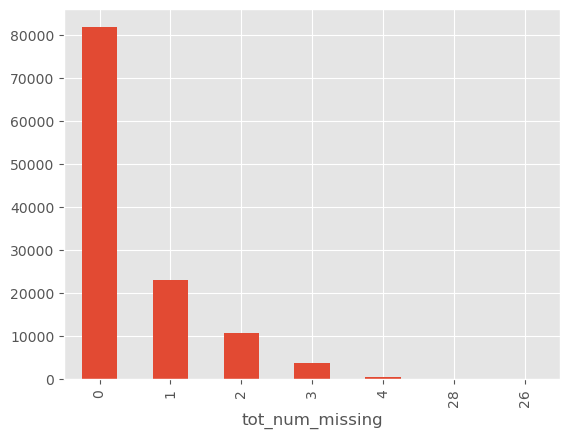

In [14]:
df['tot_num_missing'].value_counts().plot.bar(y='tot_num_missing')
plt.show()

In [15]:
ind_missing=df[df['tot_num_missing'] >=20].index
print("Rows missing more than 20 values: ",ind_missing)

Rows missing more than 20 values:  Index([160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173], dtype='int64')


In [16]:
df=df.drop(ind_missing,axis=0)
print(df.shape)

(119376, 61)


In [17]:
#drop all _missing columns
ismissing_cols = [col for col in df.columns if '_missing' in col]
df = df.drop(ismissing_cols,axis=1)
print(df.shape)

(119376, 32)


In [18]:
#Now again check how many missing values in each columns
for col in df.columns:
    pct_miss = np.mean(df[col].isnull())
    if pct_miss > 0:
        print(f"{col} - {pct_miss*100}%")
        # for this missing col, check if its numeric or categorical
        if col in nonnumeric_cols:
            # handle it like categorical - mode
            md = df[col].describe()['top']
            df[col] = df[col].fillna(md)
        else:
            #handle like numeric - replace with median
            med = df[col].median()
            df[col] = df[col].fillna(med)

children - 2.0498257606219004%
babies - 11.311318858061922%
meal - 11.467129071170085%
country - 0.40879238707947996%
deposit_type - 8.232810615199035%
agent - 13.687005763302507%


In [19]:
print("Checking one more time if any missing values")
for col in df.columns:
    pct_miss = np.mean(df[col].isnull())
    if pct_miss > 0:
        print(f"{col} - {pct_miss*100}%")

Checking one more time if any missing values
